In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import klasyfikacja_nn as klas_nn
import pickle

df=pd.read_csv('labeled_selected_routes_group_1.csv')

# przykładowo 6 równych kwantyli (możesz zmienić na 5,7)
df['delay_bin_q'] = pd.qcut(df['delay_min'].clip(lower=0), q=6, labels=False, duplicates='drop')

df[df['delay_min']<-200]

,Unnamed: 0,vehicle_id,trip_id,stop_sequence,day,planned_departure,timestamp,delay_sec,delay_min,route_name,time_label,delay_label,sin_time,cos_time,delay_bin_q
33186,274955,529,block_485_trip_6_service_1,4,1,2025-06-09 09:16:00,2025-06-09 05:14:51,-14469.0,-241.150000,503,915,0,0.659346,-0.751840,0
33187,274973,529,block_485_trip_6_service_1,4,1,2025-06-09 09:16:00,2025-06-09 05:15:21,-14439.0,-240.650000,503,915,0,0.659346,-0.751840,0
33189,274993,529,block_485_trip_6_service_1,4,1,2025-06-09 09:16:00,2025-06-09 05:15:52,-14408.0,-240.133333,503,915,0,0.659346,-0.751840,0
33193,275014,529,block_485_trip_6_service_1,4,1,2025-06-09 09:16:00,2025-06-09 05:16:22,-14378.0,-239.633333,503,915,0,0.659346,-0.751840,0
33199,275046,529,block_485_trip_6_service_1,4,1,2025-06-09 09:16:00,2025-06-09 05:16:53,-14347.0,-239.116667,503,915,0,0.659346,-0.751840,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100700,812544,569,block_988_trip_11_service_3,24,4,2025-06-19 18:13:00,2025-06-19 12:32:53,-20407.0,-340.116667,192,1810,0,-0.999048,0.043619,0
100702,812569,569,block_988_trip_11_service_3,25,4,2025-06-19 18:14:00,2025-06-19 12:34:17,-20383.0,-339.716667,192,1810,0,-0.999048,0.043619,0
108964,922605,512,block_146_trip_4_service_1,26,1,2025-06-24 08:36:00,2025-06-24 00:04:12,-30708.0,-511.800000,169,835,0,0.779884,-0.625923,0
108965,922611,512,block_146_trip_4_service_1,27,1,2025-06-24 08:37:00,2025-06-24 00:05:16,-30704.0,-511.733333,169,835,0,0.779884,-0.625923,0


In [9]:
wyniki=klas_nn.klasyfikacja_nn('labeled_selected_routes_group_3.csv',epochs=20)

wyniki_zapis=[wyniki['train_losses'],wyniki['test_losses'],wyniki['results']]

plik=open('../data/wyniki_predykcji/grupa_3_klasyfikacja_bez_cv_20_epoch','ab')
pickle.dump(wyniki_zapis,plik)
plik.close()

Epoch 1/20 | Train Loss: 1.4837 | Test Loss: 1.3748
Epoch 2/20 | Train Loss: 1.3480 | Test Loss: 1.3422
Epoch 3/20 | Train Loss: 1.3286 | Test Loss: 1.3310
Epoch 4/20 | Train Loss: 1.3150 | Test Loss: 1.3166
Epoch 5/20 | Train Loss: 1.3019 | Test Loss: 1.3129
Epoch 6/20 | Train Loss: 1.2889 | Test Loss: 1.2992
Epoch 7/20 | Train Loss: 1.2776 | Test Loss: 1.2863
Epoch 8/20 | Train Loss: 1.2687 | Test Loss: 1.2823
Epoch 9/20 | Train Loss: 1.2593 | Test Loss: 1.2820
Epoch 10/20 | Train Loss: 1.2513 | Test Loss: 1.2737
Epoch 11/20 | Train Loss: 1.2446 | Test Loss: 1.2762
Epoch 12/20 | Train Loss: 1.2388 | Test Loss: 1.2678
Epoch 13/20 | Train Loss: 1.2317 | Test Loss: 1.2620
Epoch 14/20 | Train Loss: 1.2265 | Test Loss: 1.2574
Epoch 15/20 | Train Loss: 1.2206 | Test Loss: 1.2575
Epoch 16/20 | Train Loss: 1.2162 | Test Loss: 1.2599
Epoch 17/20 | Train Loss: 1.2122 | Test Loss: 1.2532
Epoch 18/20 | Train Loss: 1.2073 | Test Loss: 1.2578
Epoch 19/20 | Train Loss: 1.2011 | Test Loss: 1.2555
Ep

<Figure size 1200x500 with 0 Axes>

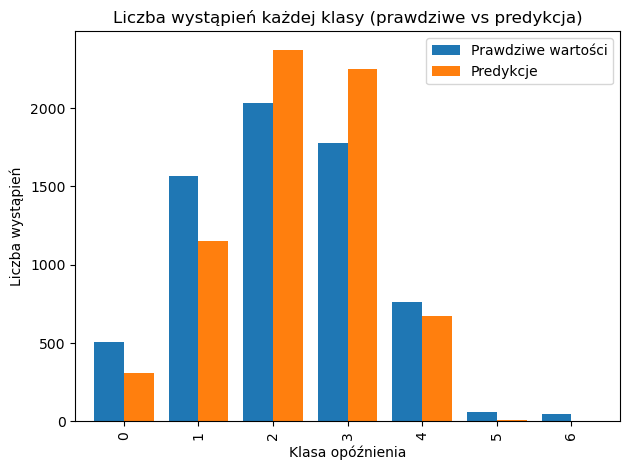

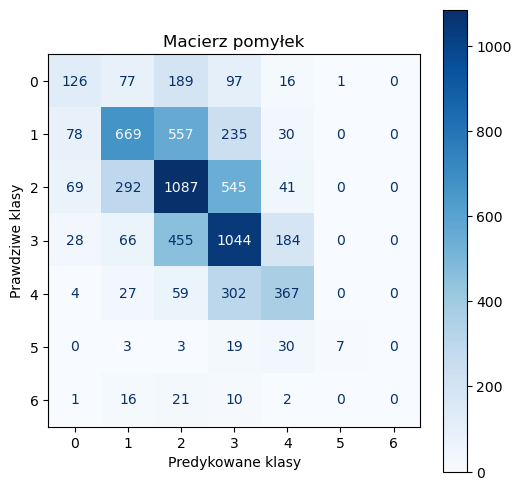

In [10]:
df_results = wyniki['results']
df_results

plt.figure(figsize=(12,5))
y_true_counts = df_results['y_true'].value_counts().sort_index()
y_pred_counts = df_results['y_pred'].value_counts().sort_index()

df_counts = pd.DataFrame({
    "Prawdziwe wartości": y_true_counts,
    "Predykcje": y_pred_counts
}).fillna(0).astype(int)

df_counts.plot(kind="bar", width=0.8)
plt.xlabel("Klasa opóźnienia")
plt.ylabel("Liczba wystąpień")
plt.title("Liczba wystąpień każdej klasy (prawdziwe vs predykcja)")
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(df_results['y_true'], df_results['y_pred'])
classes = sorted(df_results['y_true'].unique())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title(f"Macierz pomyłek")
plt.xlabel("Predykowane klasy")
plt.ylabel("Prawdziwe klasy")
plt.show()

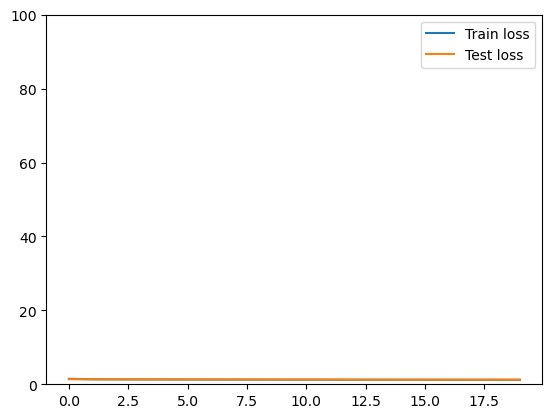

In [ ]:
plt.figure
plt.plot(wyniki['train_losses'],label='Train loss')
plt.plot(wyniki['test_losses'],label='Test loss')
plt.ylim([0,10])
plt.legend()
plt.show()

In [12]:
wyniki=klas_nn.klasyfikacja_nn_cv('labeled_selected_routes_group_3.csv',epochs=20)

plik=open('../data/wyniki_predykcji/grupa_3_klasyfikacja_5cv_20_epoch','ab')
pickle.dump(wyniki,plik)
plik.close()


===== Fold 1/5 =====
Avg train loss in epoch 0:1.4848
Avg train loss in epoch 1:1.3435
Avg train loss in epoch 2:1.3227
Avg train loss in epoch 3:1.3071
Avg train loss in epoch 4:1.2958
Avg train loss in epoch 5:1.2846
Avg train loss in epoch 6:1.2763
Avg train loss in epoch 7:1.2680
Avg train loss in epoch 8:1.2602
Avg train loss in epoch 9:1.2514
Avg train loss in epoch 10:1.2478
Avg train loss in epoch 11:1.2408
Avg train loss in epoch 12:1.2365
Avg train loss in epoch 13:1.2301
Avg train loss in epoch 14:1.2242
Avg train loss in epoch 15:1.2203
Avg train loss in epoch 16:1.2171
Avg train loss in epoch 17:1.2123
Avg train loss in epoch 18:1.2080
Avg train loss in epoch 19:1.2041
Fold 1 | Train loss: 1.2041 | Val loss: 1.2592

===== Fold 2/5 =====
Avg train loss in epoch 0:1.4794
Avg train loss in epoch 1:1.3404
Avg train loss in epoch 2:1.3209
Avg train loss in epoch 3:1.3062
Avg train loss in epoch 4:1.2926
Avg train loss in epoch 5:1.2831
Avg train loss in epoch 6:1.2731
Avg trai

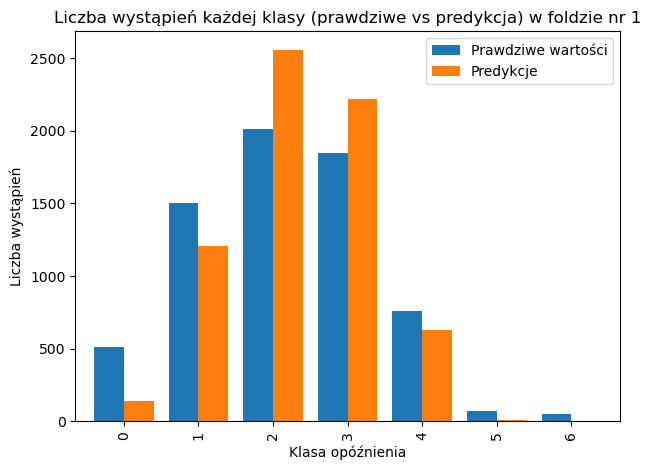

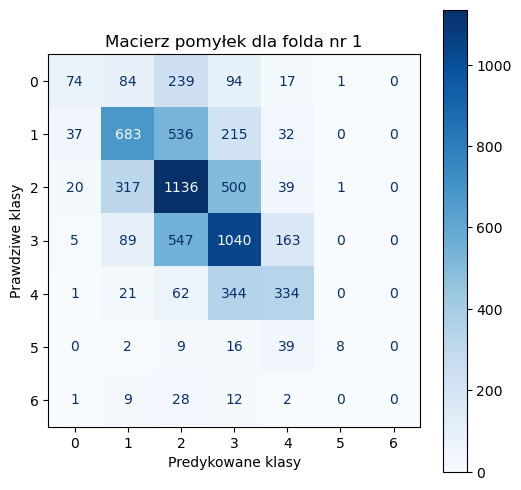

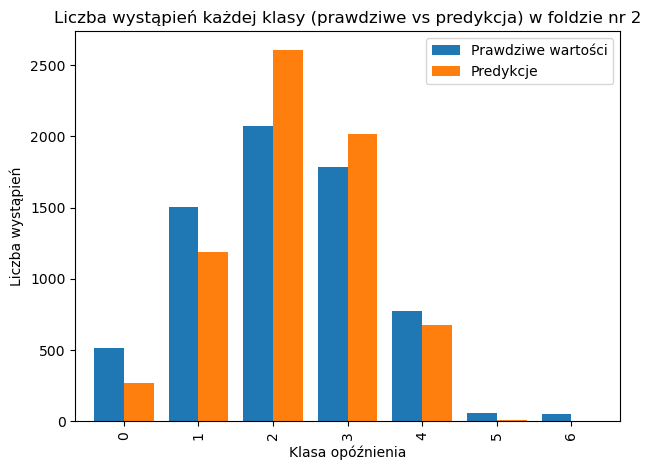

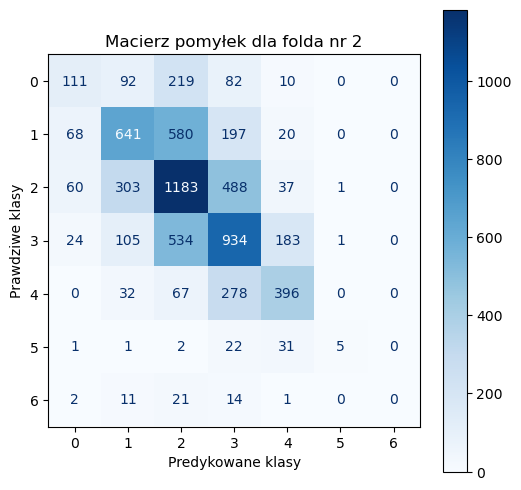

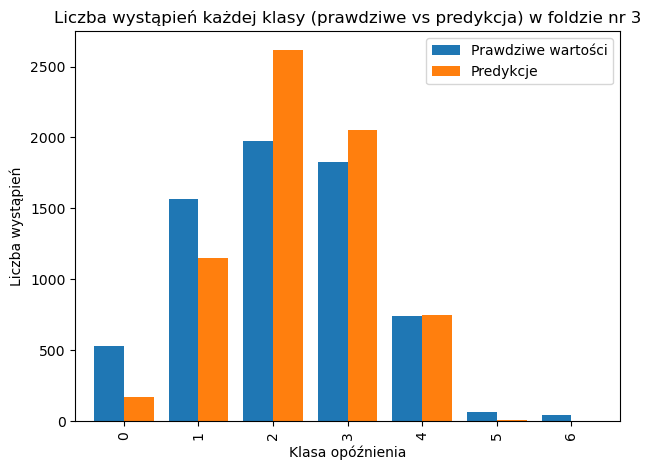

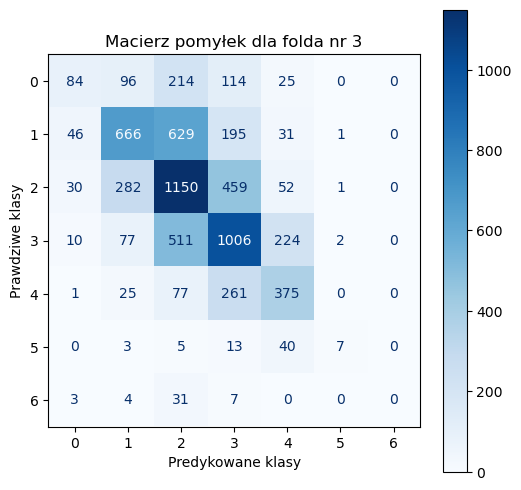

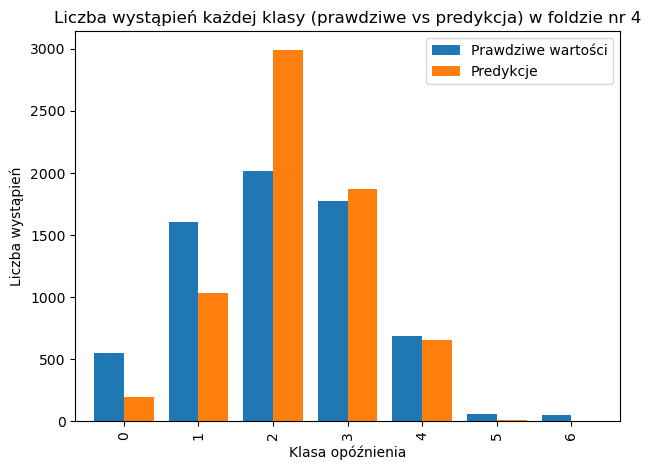

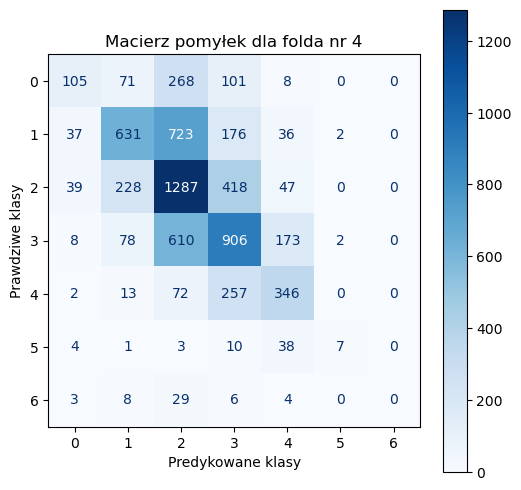

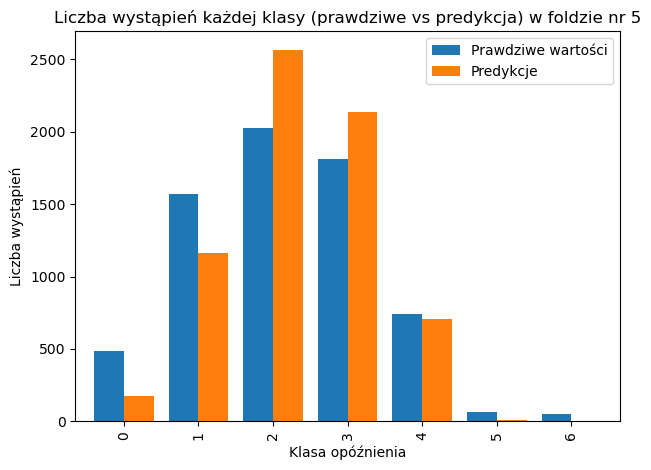

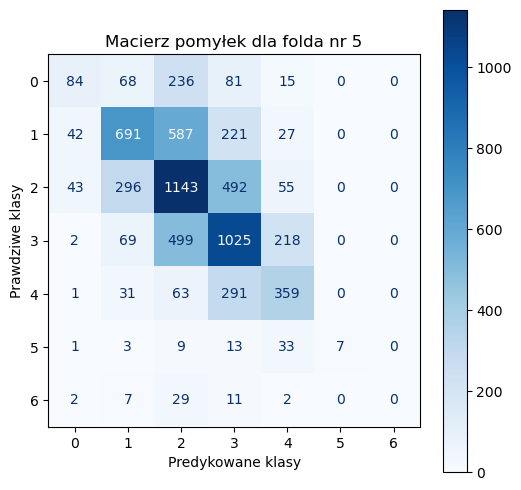

In [13]:

for i in range(5):
    predykcje=wyniki['fold_preds'][i]
    y_true_counts = predykcje['y_true'].value_counts().sort_index()
    y_pred_counts = predykcje['y_pred'].value_counts().sort_index()
    df_counts = pd.DataFrame({
    "Prawdziwe wartości": y_true_counts,
    "Predykcje": y_pred_counts
    }).fillna(0).astype(int)

    df_counts.plot(kind="bar", width=0.8)
    plt.xlabel("Klasa opóźnienia")
    plt.ylabel("Liczba wystąpień")
    plt.title(f"Liczba wystąpień każdej klasy (prawdziwe vs predykcja) w foldzie nr {i+1}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    

    # Oblicz macierz pomyłek
    cm = confusion_matrix(predykcje['y_true'], predykcje['y_pred'])
    classes = sorted(predykcje['y_true'].unique())

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f"Macierz pomyłek dla folda nr {i+1}")
    plt.xlabel("Predykowane klasy")
    plt.ylabel("Prawdziwe klasy")
    plt.show()

